In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading the dataset
df = pd.read_csv("C:/Users/Hp/Documents/COS/gamedariCOS102/week 12/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47,1


In [3]:
#getting info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


## Data Cleaning

In [4]:
#counting null values in each column
df.isna().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [5]:
#checking the shape of the dataframe
df.shape

(768, 9)

In [6]:
#filling the null values in Insulin column with the mean value
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].mean())

In [7]:
#filling the null values in BloodPressure, SkinThickness and BMI column with the median value
to_fill = ['BloodPressure','SkinThickness', 'BMI']
for col in to_fill:
    df[col] = df[col].fillna(df[col].median())

In [8]:
df.isna().sum()

Pregnancies                 0
Glucose                     5
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
#dropping any row that contains a null value and making the change permanent
df.dropna(inplace = True)

In [10]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [11]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.0,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.0,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.000000,32.9,0.171,63,0
764,2,122.0,70.0,27.0,155.548223,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.000000,26.2,0.245,30,0
766,1,126.0,60.0,29.0,155.548223,30.1,0.349,47,1


## Exploratory Data Analysis

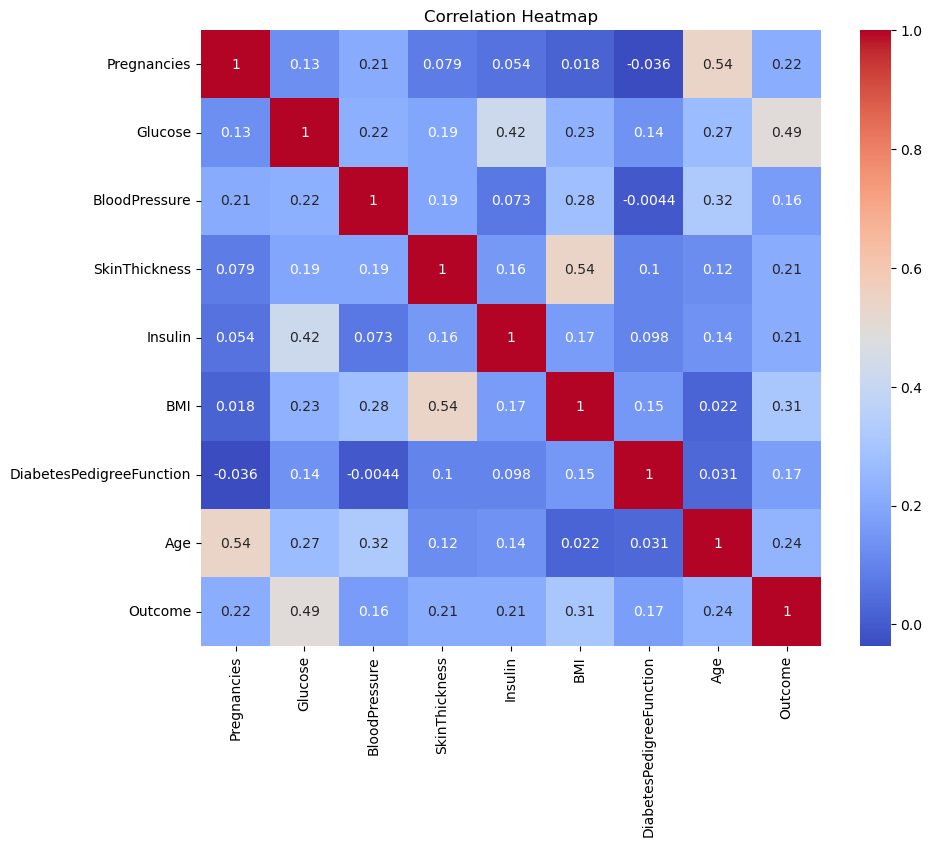

In [12]:
#Plotting the correlation heatmap of the dataset
plt.figure(figsize = (10,8))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [13]:
#Checking out the plain correlation data
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128135,0.207161,0.079325,0.054488,0.018216,-0.036063,0.542558,0.218877
Glucose,0.128135,1.000000,0.219236,0.193258,0.420825,0.231765,0.137246,0.267136,0.494650
BloodPressure,0.207161,0.219236,1.000000,0.191194,0.073123,0.279443,-0.004387,0.323907,0.164187
SkinThickness,0.079325,0.193258,0.191194,1.000000,0.156741,0.541679,0.099584,0.123589,0.211906
Insulin,0.054488,0.420825,0.073123,0.156741,1.000000,0.165922,0.097858,0.135132,0.214009
BMI,0.018216,0.231765,0.279443,0.541679,0.165922,1.000000,0.151755,0.021944,0.308250
DiabetesPedigreeFunction,-0.036063,0.137246,-0.004387,0.099584,0.097858,0.151755,1.000000,0.030896,0.172292
Age,0.542558,0.267136,0.323907,0.123589,0.135132,0.021944,0.030896,1.000000,0.235145
Outcome,0.218877,0.494650,0.164187,0.211906,0.214009,0.308250,0.172292,0.235145,1.000000


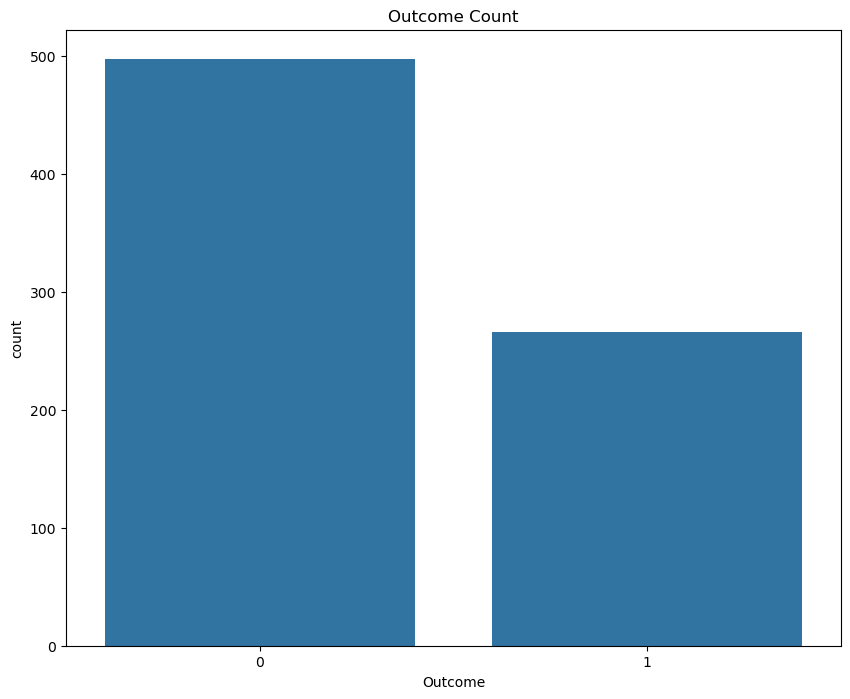

In [14]:
#Counting the diabetic vs the non diabetic patients
plt.figure(figsize=(10, 8))
sns.countplot(x='Outcome', data=df)
plt.title("Outcome Count")
plt.show()

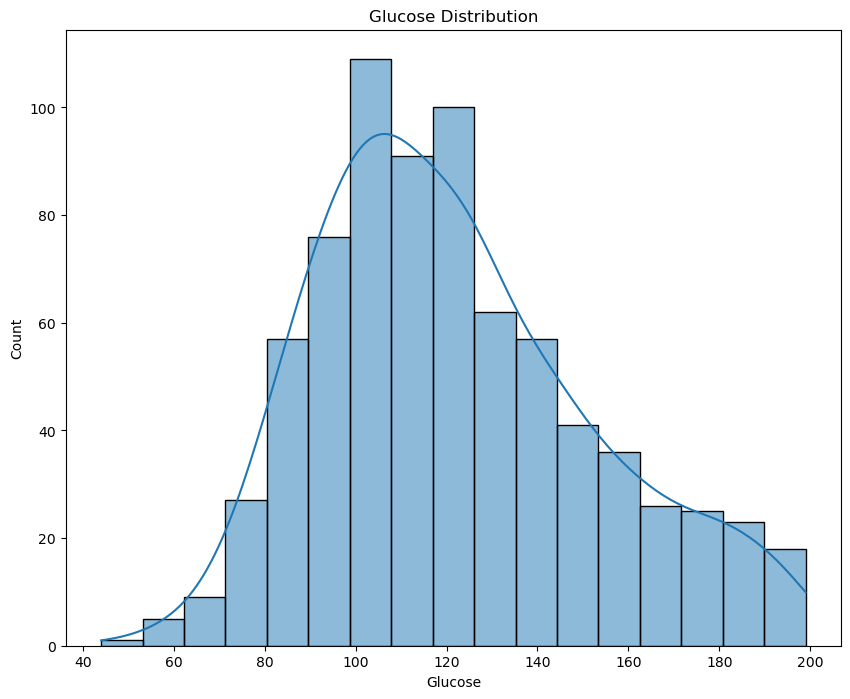

In [15]:
#Analyzing the distribution of the glucose level of the patients that make up the dataset
plt.figure(figsize=(10, 8))
sns.histplot(df['Glucose'], kde=True)
plt.title("Glucose Distribution")
plt.show()

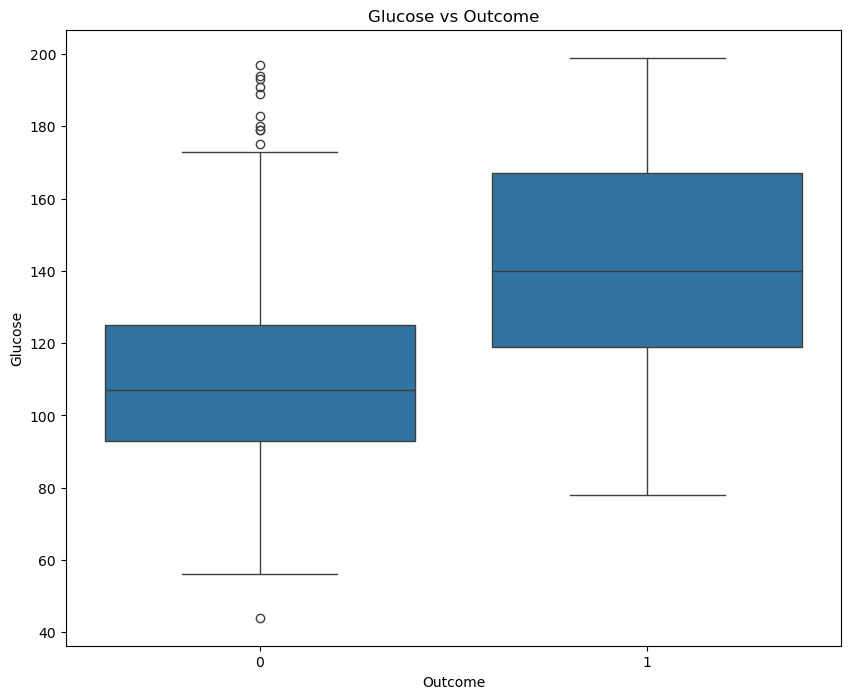

In [16]:
#Comparing the glucose distibution between the diabetic and non diabetic patients
plt.figure(figsize=(10, 8))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title("Glucose vs Outcome")
plt.show()

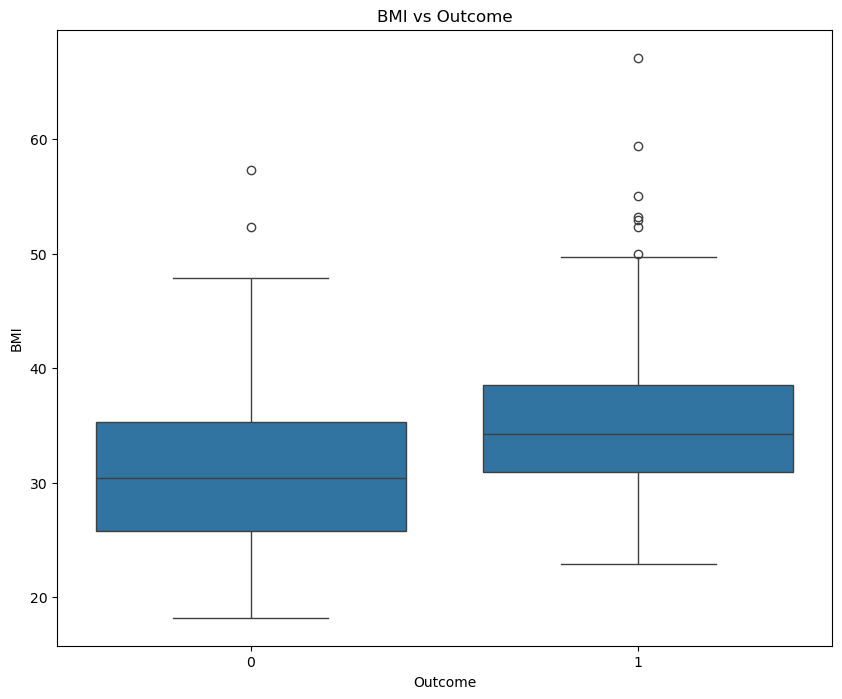

In [17]:
#Comparing the BMI distibution between the diabetic and non diabetic patients
plt.figure(figsize=(10, 8))
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title("BMI vs Outcome")
plt.show()

In [18]:
#Calculating the average values of each feature for diabetic and non-diabetic
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.311871,110.643863,70.965795,27.742455,142.396950,30.902213,0.430662,31.247485
1,4.860902,142.319549,75.131579,31.650376,180.618641,35.348872,0.550605,37.052632
